In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!tar -xzf '/content/drive/MyDrive/Ketastasia/data/frame_cache.tar.gz' -C '/content/'

In [3]:
import sys
import torchvision.transforms.functional as F
# PytorchVideo-ს ძველი იმპორტის fix ახალი ვერსიებისთვის
sys.modules['torchvision.transforms.functional_tensor'] = F

!pip install pytorchvideo wandb decord -q

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import wandb
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 17.7 MB/s eta 0:00:00


In [4]:
manifest = pd.read_csv('/content/drive/MyDrive/Ketastasia/data/combined_cached_final.csv')
classes = sorted(manifest['label'].unique())
label2idx = {c: i for i, c in enumerate(classes)}
NUM_CLASSES = len(classes)

train_df = manifest[manifest['split'] == 'train'].reset_index(drop=True)
val_df   = manifest[manifest['split'] == 'val'].reset_index(drop=True)

class PackPathway(torch.nn.Module):
    def __init__(self, alpha=4):
        super().__init__()
        self.alpha = alpha
    def forward(self, frames):
        fast_pathway = frames
        slow_idx = torch.linspace(0, frames.shape[1] - 1, frames.shape[1] // self.alpha).long()
        slow_pathway = torch.index_select(frames, 1, slow_idx)
        return [slow_pathway, fast_pathway]

class CachedClipDataset(Dataset):
    def __init__(self, df, label2idx, transform=None):
        self.df = df.reset_index(drop=True)
        self.label2idx = label2idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = np.load(row['cache_path']) # (32, 256, 256, 3)
        clip = torch.from_numpy(frames).permute(3, 0, 1, 2).float() / 255.0 # (C, T, H, W)
        if self.transform:
            clip = self.transform(clip)
        label = self.label2idx[row['label']]
        return clip, label

def slowfast_collate(batch):
    slow_list = torch.stack([item[0][0] for item in batch])
    fast_list = torch.stack([item[0][1] for item in batch])
    labels = torch.tensor([item[1] for item in batch])
    return [slow_list, fast_list], labels

class imbalance

In [5]:
beta = 0.999
class_counts = train_df['label'].value_counts().reindex(classes).values
effective_num = 1.0 - np.power(beta, class_counts)
weights = (1.0 - beta) / effective_num
weights = weights / weights.sum() * NUM_CLASSES
class_weights = torch.tensor(weights, dtype=torch.float32)

In [6]:
def evaluate(model, loader, device, criterion_fn):
    model.eval()
    all_preds, all_labels = [], []
    val_loss = 0
    with torch.no_grad():
        for (slow, fast), labels in loader:
            slow, fast, labels = slow.to(device), fast.to(device), labels.to(device)
            with torch.cuda.amp.autocast():
                outputs = model([slow, fast])
                loss = criterion_fn(outputs, labels)
            val_loss += loss.item()
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    report = classification_report(all_labels, all_preds, target_names=classes, zero_division=0)
    return val_loss / len(loader), acc, macro_f1, report

In [7]:
# CELL 3.1 — CONFIG: Baseline
CONFIG = {
    "project_name": "ildolcefarniente",
    "group_name": "p3_SlowFast",
    "run_name": "SlowFast-R50_Base_LR-1e-4_NoWeights",

    "lr": 1e-4,
    "batch_size": 8,
    "weight_decay": 1e-4,
    "epochs": 30,
    "patience": 10,

    "model_name": "slowfast_r50",
    "alpha": 4,
    "crop_size": 224,
    "class_weighted": False, # ჩვეულებრივი Loss
    "use_sampler": False
}

In [14]:
# CELL 3.2 — CONFIG: Effective Number Weights
CONFIG = {
    "project_name": "ildolcefarniente",
    "group_name": "p3_SlowFast",
    "run_name": "SlowFast-R50_EffNumWeights_LR-1e-4",

    "lr": 1e-4,
    "batch_size": 8,
    "weight_decay": 1e-4,
    "epochs": 30,
    "patience": 10,

    "model_name": "slowfast_r50",
    "alpha": 4,
    "crop_size": 224,
    "class_weighted": True,  # წონიანი Loss
    "use_sampler": False
}

In [ ]:
# CELL 3.3 — CONFIG: Higher LR with Weights
CONFIG = {
    "project_name": "ildolcefarniente",
    "group_name": "p3_SlowFast",
    "run_name": "SlowFast-R50_EffNumWeights_LR-3e-4",

    "lr": 3e-4,              # უფრო მაღალი სწავლის ტემპი
    "batch_size": 8,
    "weight_decay": 1e-4,
    "epochs": 30,
    "patience": 10,

    "model_name": "slowfast_r50",
    "alpha": 4,
    "crop_size": 224,
    "class_weighted": True,
    "use_sampler": False
}

In [20]:
# CELL 3.4 — CONFIG: Sampler Fallback
CONFIG = {
    "project_name": "ildolcefarniente",
    "group_name": "p3_SlowFast",
    "run_name": "SlowFast-R50_CappedSampler-4x_NoWeights",

    "lr": 1e-4,
    "batch_size": 8,
    "weight_decay": 1e-4,
    "epochs": 30,
    "patience": 10,

    "model_name": "slowfast_r50",
    "alpha": 4,
    "crop_size": 224,
    "class_weighted": False, # სემპლერის დროს Loss უწონო უნდა იყოს!
    "use_sampler": True      # ააქტიურებს წინა პასუხში მოცემულ სემპლერის ლოგიკას
}

In [21]:
from pytorchvideo.transforms import ShortSideScale
from torchvision.transforms import Compose, CenterCrop, RandomCrop, RandomHorizontalFlip

MEAN = [0.45, 0.45, 0.45]
STD  = [0.225, 0.225, 0.225]

def normalize(x):
    mean = torch.tensor(MEAN).view(3,1,1,1)
    std  = torch.tensor(STD).view(3,1,1,1)
    return (x - mean) / std

train_transform = Compose([
    normalize,
    ShortSideScale(size=256),
    RandomCrop(CONFIG["crop_size"]),
    RandomHorizontalFlip(p=0.5),
    PackPathway(alpha=CONFIG["alpha"]),
])

val_transform = Compose([
    normalize,
    ShortSideScale(size=256),
    CenterCrop(CONFIG["crop_size"]),
    PackPathway(alpha=CONFIG["alpha"]),
])

train_ds = CachedClipDataset(train_df, label2idx, transform=train_transform)
val_ds   = CachedClipDataset(val_df, label2idx, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2, collate_fn=slowfast_collate, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, collate_fn=slowfast_collate, pin_memory=True)

3.4 config-ისთვის

In [22]:
# CELL 2 — DataLoaders შერჩევა CONFIG-ის მიხედვით
if CONFIG["use_sampler"]:
    class_counts = train_df['label'].value_counts().reindex(classes).values
    class_weights_sampler = 1.0 / class_counts
    sample_weights = [class_weights_sampler[label2idx[row['label']]] for _, row in train_df.iterrows()]

    sampler = torch.utils.data.WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    # ყურადღება: shuffle=True აქ არ გვინდა, რადგან სემპლერი თავად არევს დატას!
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, num_workers=2, collate_fn=slowfast_collate, pin_memory=True)
    print("✅ WeightedRandomSampler წარმატებით გააქტიურდა!")
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=2, collate_fn=slowfast_collate, pin_memory=True)
    print("ℹ️ გამოიყენება ჩვეულებრივი Shuffle ლაოდერი.")

val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, collate_fn=slowfast_collate, pin_memory=True)

✅ WeightedRandomSampler წარმატებით გააქტიურდა!


In [16]:
from google.colab import userdata

wandb_api_key = userdata.get('WANDB_API_KEY_1')
wandb.login(key=wandb_api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [23]:


wandb.init(
    project=CONFIG["project_name"],
    group=CONFIG["group_name"],
    name=CONFIG["run_name"],
    config=CONFIG
)

# პრეტრეინირებული SlowFast-ის ჩატვირთვა
model = torch.hub.load('facebookresearch/pytorchvideo', CONFIG["model_name"], pretrained=True)
in_features = model.blocks[-1].proj.in_features
model.blocks[-1].proj = nn.Linear(in_features, NUM_CLASSES)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

# CONFIG-ის მიხედვით ვირჩევთ წონიან ან ჩვეულებრივ Loss-ს
if CONFIG["class_weighted"]:
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
else:
    criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
scaler = torch.cuda.amp.GradScaler()

Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main
/tmp/ipykernel_491/2931475237.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
best_val_macro_f1 = 0
patience_counter = 0
best_report = "ტრენინგი ადრეულ ეტაპზე შეწყდა და რეპორტი არ გენერირებულა."

print(f"🔥 ტრენინგი დაიწყო ექსპერიმენტისთვის: {CONFIG['run_name']}")

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss = 0
    all_train_preds = []
    all_train_labels = []

    for (slow, fast), labels in train_loader:
        slow, fast, labels = slow.to(device), fast.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model([slow, fast])
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        all_train_preds.extend(outputs.argmax(1).cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())

    # ტრენინგის ეპოქის მეტრიკები Overfitting-ის შესაფასებლად
    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = (np.array(all_train_preds) == np.array(all_train_labels)).mean()
    epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro', zero_division=0)

    # ვალიდაცია
    val_loss, val_acc, val_macro_f1, report = evaluate(model, val_loader, device, criterion)
    scheduler.step()

    # სრული მეტრიკების გაგზავნა WandB-ზე იდეალური გრაფებისთვის
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": epoch_train_loss,
        "train/acc": epoch_train_acc,
        "train/macro_f1": epoch_train_f1,
        "val/loss": val_loss,
        "val/acc": val_acc,
        "val/macro_f1": val_macro_f1
    })

    print(f"Epoch {epoch+1:02d}: Train Loss={epoch_train_loss:.4f} | Val Loss={val_loss:.4f} | Train F1={epoch_train_f1:.4f} | Val F1={val_macro_f1:.4f}")

    # საუკეთესო მოდელის შენახვა ლოკალურად (/content/)
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        patience_counter = 0
        model_save_path = f'/content/{CONFIG["run_name"]}_best.pt'
        torch.save(model.state_dict(), model_save_path)
        print(f"    🎉 ახალი საუკეთესო მოდელი შეინახა ლოკალურად: {val_macro_f1:.4f}")
        best_report = report
    else:
        patience_counter += 1
        if patience_counter >= CONFIG["patience"]:
            print("🛑 Early stopping ამოქმედდა. პროცესი შეწყდა.")
            break

print("\n🏆 === საუკეთესო Epoch-ის Classification Report ===")
print(best_report)
wandb.finish()

🔥 ტრენინგი დაიწყო ექსპერიმენტისთვის: SlowFast-R50_CappedSampler-4x_NoWeights


/tmp/ipykernel_491/2274315792.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_491/4288790524.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 01: Train Loss=1.5707 | Val Loss=0.1956 | Train F1=0.7063 | Val F1=0.9269
    🎉 ახალი საუკეთესო მოდელი შეინახა ლოკალურად: 0.9269


/tmp/ipykernel_491/2274315792.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_491/4288790524.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 02: Train Loss=0.2494 | Val Loss=0.1347 | Train F1=0.9739 | Val F1=0.9468
    🎉 ახალი საუკეთესო მოდელი შეინახა ლოკალურად: 0.9468


...

/tmp/ipykernel_491/2274315792.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_491/4288790524.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 08: Train Loss=0.0336 | Val Loss=0.0980 | Train F1=0.9984 | Val F1=0.9709
    🎉 ახალი საუკეთესო მოდელი შეინახა ლოკალურად: 0.9709


/tmp/ipykernel_491/2274315792.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_491/4288790524.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 09: Train Loss=0.0174 | Val Loss=0.0922 | Train F1=0.9969 | Val F1=0.9678


/tmp/ipykernel_491/2274315792.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


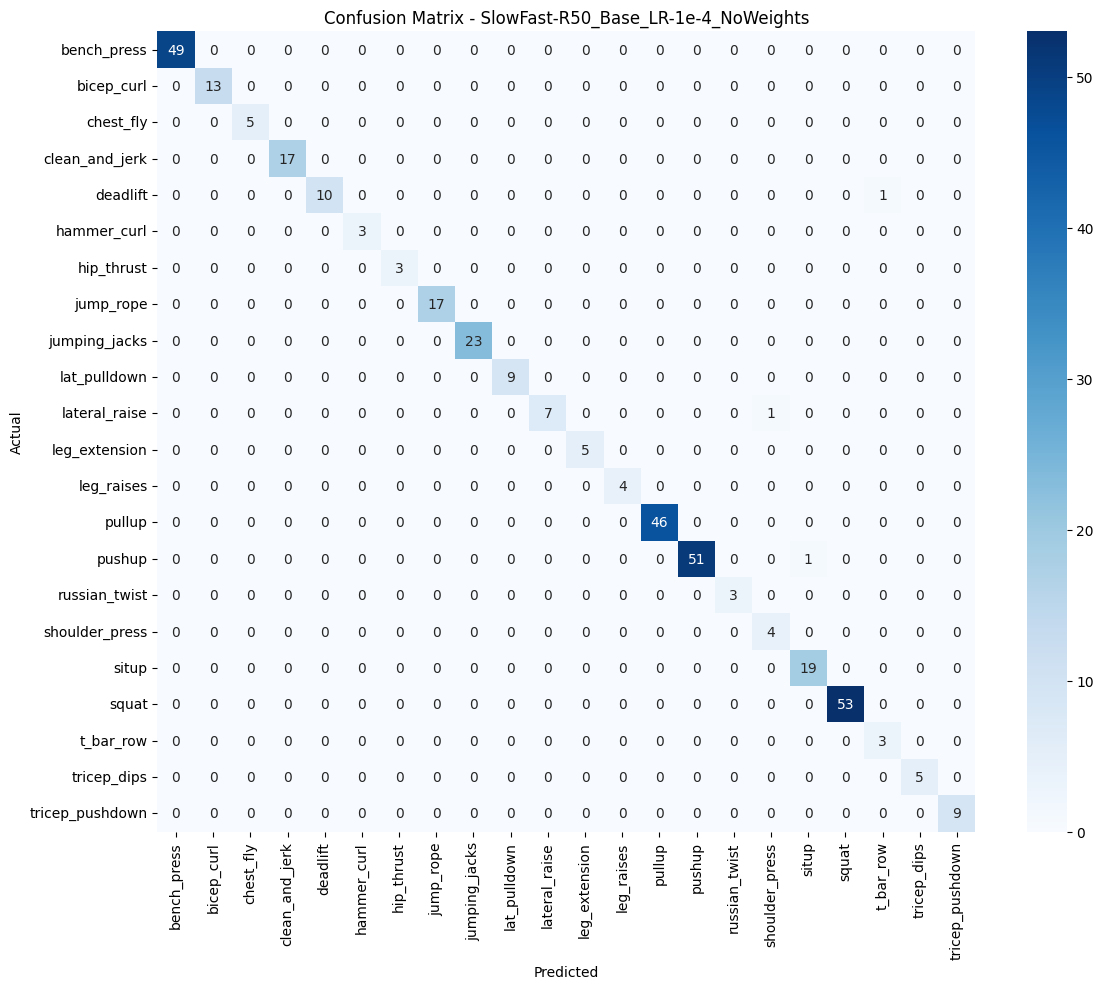

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# საუკეთესო მოდელის ხელახლა ჩატვირთვა სატესტოდ (დროებითი მეხსიერებიდან)
model.load_state_dict(torch.load(f'/content/{CONFIG["run_name"]}_best.pt'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for (slow, fast), labels in val_loader:
        slow, fast = slow.to(device), fast.to(device)
        outputs = model([slow, fast])
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# მატრიცის აგება
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title(f'Confusion Matrix - {CONFIG["run_name"]}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=90)
plt.tight_layout()

# სურათის შენახვა README-სთვის
plt.savefig(f'/content/{CONFIG["run_name"]}_confusion_matrix.png')
plt.show()